#  Evaluación Parcial N°1 — Fundamentos de Deep Learning
## Asignatura: DLY0100 — Deep Learning
### Dataset: Fashion-MNIST | Framework: TensorFlow / Keras

---

##  Introducción

### Descripción del problema

**Fashion-MNIST** es un dataset de imágenes en escala de grises de 28×28 píxeles, cada una perteneciente a una de **10 categorías** de prendas de vestir. Fue creado por Zalando como reemplazo del clásico MNIST de dígitos, ya que representa un desafío de clasificación más realista y complejo.

| Etiqueta | Clase |
|----------|-------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

### Objetivo del modelo

Implementar una **Red Neuronal Multicapa (MLP)** capaz de clasificar correctamente cada imagen en su categoría correspondiente. Se evaluarán distintas configuraciones de hiperparámetros, funciones de activación, técnicas de regularización y optimización, documentando el impacto de cada decisión en el rendimiento final del modelo.

### Estructura del notebook

1. Instalación de dependencias y librerías
2. Carga y preprocesamiento de datos
3. Definición del modelo MLP base
4. Experimentos controlados: impacto de hiperparámetros
5. Comparación de funciones de activación y error
6. Optimización: Dropout y Batch Normalization
7. Evaluación con métricas: Accuracy, Precision, Recall, F1-Score
8. Análisis comparativo de configuraciones
9. Conclusiones

---
## 1.  Instalación de Dependencias

In [9]:
# Importamos librerías necesarias
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Fijar semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
print(' Librerías cargadas correctamente')

TensorFlow version: 2.19.0
Keras version: 3.13.2
 Librerías cargadas correctamente


---
## 2.  Carga y Preprocesamiento de Datos

### Decisiones de preprocesamiento

| Paso | Técnica | Justificación |
|------|---------|---------------|
| Normalización | Dividir por 255.0 | Escala los píxeles al rango [0, 1], lo que mejora la convergencia del gradiente y evita que neuronas con pesos grandes dominen el entrenamiento |
| Aplanado (Flatten) | Reshape (28,28) → (784,) | Las redes MLP operan sobre vectores 1D; cada imagen de 28×28 se convierte en un vector de 784 dimensiones |
| One-Hot Encoding | No aplicado | Se usa `sparse_categorical_crossentropy` que acepta etiquetas enteras directamente, reduciendo memoria |
| Split | Train/Test ya dividido por Keras | 60.000 imágenes de entrenamiento, 10.000 de test. Se reserva 20% del train como validación |

In [10]:
# Carga del dataset Fashion-MNIST
fashion_mnist = keras.datasets.fashion_mnist
(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

# Nombres de las clases
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Dimensiones originales')
print(f'X_train: {X_train_raw.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test_raw.shape}  |  y_test : {y_test.shape}')
print(f'\nRango de valores de píxeles: [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Clases: {np.unique(y_train)}')

Dimensiones originales
X_train: (60000, 28, 28)  |  y_train: (60000,)
X_test : (10000, 28, 28)  |  y_test : (10000,)

Rango de valores de píxeles: [0, 255]
Clases: [0 1 2 3 4 5 6 7 8 9]


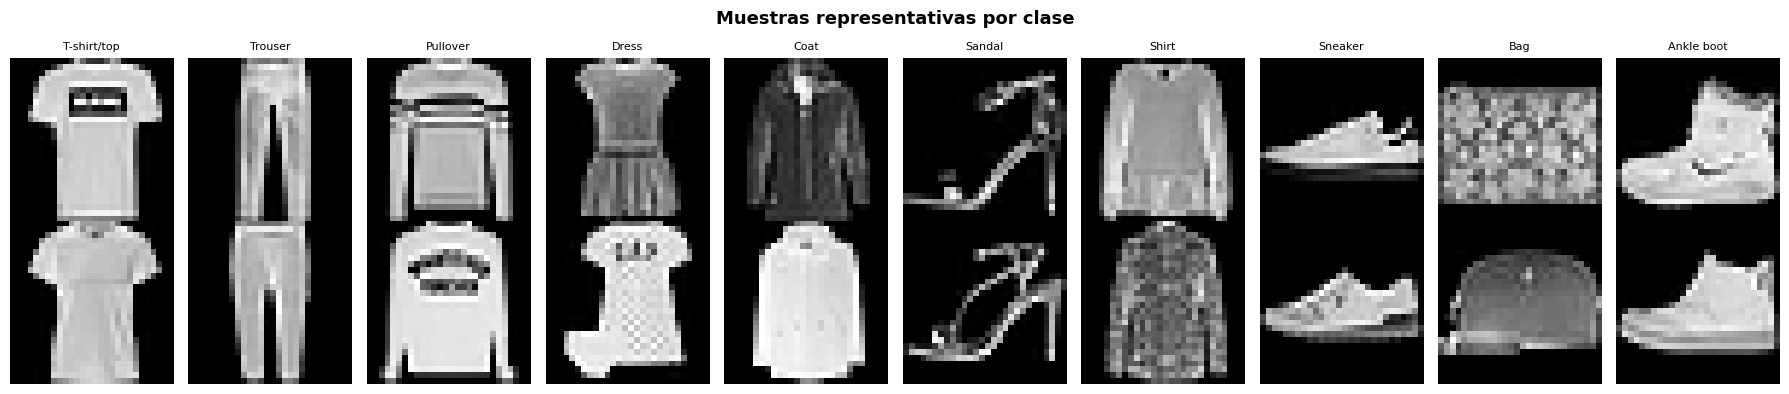

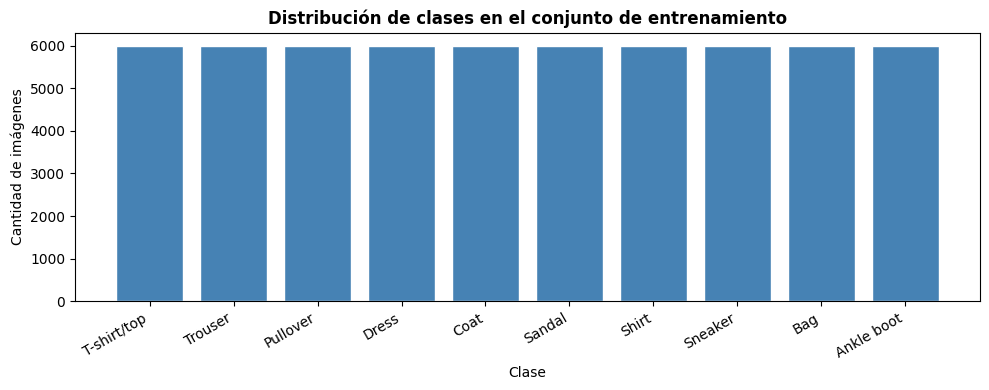

In [11]:
# Exploración visual del dataset
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for label_idx in range(10):
    # Tomar una imagen representativa de cada clase
    idx = np.where(y_train == label_idx)[0][0]
    axes[0, label_idx].imshow(X_train_raw[idx], cmap='gray')
    axes[0, label_idx].set_title(CLASS_NAMES[label_idx], fontsize=8)
    axes[0, label_idx].axis('off')
    # Segunda muestra aleatoria de la misma clase
    idx2 = np.where(y_train == label_idx)[0][10]
    axes[1, label_idx].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, label_idx].axis('off')

plt.suptitle('Muestras representativas por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribución de clases
fig, ax = plt.subplots(figsize=(10, 4))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='white')
ax.set_title('Distribución de clases en el conjunto de entrenamiento', fontweight='bold')
ax.set_xlabel('Clase'); ax.set_ylabel('Cantidad de imágenes')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


In [12]:
# Preprocesamiento
# Paso 1: Normalización
X_train_norm = X_train_raw / 255.0
X_test_norm  = X_test_raw  / 255.0

# Paso 2: Aplanado
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)   # (60000, 784)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)     # (10000, 784)

# Paso 3: División en train / validación (80% / 20% del train original)
VAL_SPLIT = 0.2
n_val = int(len(X_train_flat) * VAL_SPLIT)

X_val   = X_train_flat[:n_val];  y_val   = y_train[:n_val]
X_train = X_train_flat[n_val:];  y_train_f = y_train[n_val:]

print('Dimensiones tras el preprocesamiento')
print(f'X_train : {X_train.shape}  |  y_train: {y_train_f.shape}')
print(f'X_val   : {X_val.shape}   |  y_val  : {y_val.shape}')
print(f'X_test  : {X_test_flat.shape}   |  y_test : {y_test.shape}')
print(f'\nRango normalizado: [{X_train.min():.2f}, {X_train.max():.2f}]')


Dimensiones tras el preprocesamiento
X_train : (48000, 784)  |  y_train: (48000,)
X_val   : (12000, 784)   |  y_val  : (12000,)
X_test  : (10000, 784)   |  y_test : (10000,)

Rango normalizado: [0.00, 1.00]


---
## 3.  Definición del Modelo MLP Base

### Arquitectura

Se define un MLP de 3 capas ocultas como modelo de referencia (*baseline*):

```
Input(784) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)
```

**Justificación de la arquitectura base:**
- **ReLU** en capas ocultas: evita el problema del gradiente desvaneciente y es computacionalmente eficiente.
- **Softmax** en la salida: convierte los logits en probabilidades que suman 1, adecuado para clasificación multiclase.
- **256 → 128 → 64**: reducción progresiva de neuronas (embudo) que fuerza al modelo a aprender representaciones más compactas y abstractas.

In [13]:
# Función auxiliar para construir modelos MLP
def build_mlp(
    hidden_units=(256, 128, 64),
    activation='relu',
    output_activation='softmax',
    dropout_rate=0.0,
    use_batch_norm=False,
    l2_lambda=0.0,
    learning_rate=1e-3,
    loss='sparse_categorical_crossentropy'
):
    """
    Construye un MLP configurable.

    Parámetros
    ----------
    hidden_units    : tupla con el número de neuronas por capa oculta
    activation      : función de activación para capas ocultas
    output_activation: función de activación de la capa de salida
    dropout_rate    : fracción de neuronas a desactivar aleatoriamente (0 = sin dropout)
    use_batch_norm  : si True, aplica Batch Normalization tras cada capa oculta
    l2_lambda       : coeficiente de regularización L2 (0 = sin regularización)
    learning_rate   : tasa de aprendizaje del optimizador Adam
    loss            : función de pérdida
    """
    model = keras.Sequential(name='MLP_FashionMNIST')
    model.add(layers.Input(shape=(784,)))  # capa de entrada

    for units in hidden_units:
        reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None
        model.add(layers.Dense(units, activation=activation, kernel_regularizer=reg))
        if use_batch_norm:
            model.add(layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, seed=SEED))

    model.add(layers.Dense(10, activation=output_activation))  # capa de salida

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=['accuracy']
    )
    return model


# Función auxiliar para entrenar y graficar
def train_model(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=64, label=''):
    """Entrena el modelo con EarlyStopping y retorna el historial."""
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0
    )
    return history


def plot_history(history, title='Entrenamiento'):
    """Grafica loss y accuracy de entrenamiento y validación."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss',  color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',    color='tomato', linestyle='--')
    axes[0].set_title(f'{title} — Loss'); axes[0].set_xlabel('Época'); axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Acc',  color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',    color='tomato', linestyle='--')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].set_xlabel('Época'); axes[1].legend()
    plt.tight_layout(); plt.show()


def get_metrics(model, X, y_true, label=''):
    """Calcula y retorna las métricas principales del modelo."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    metrics = {
        'Configuración': label,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }
    return metrics, y_pred


# Modelo base
model_base = build_mlp()
model_base.summary()

Model: "MLP_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

 Entrenando modelo base (ReLU | LR=0.001 | Batch=64 | Epochs=30)


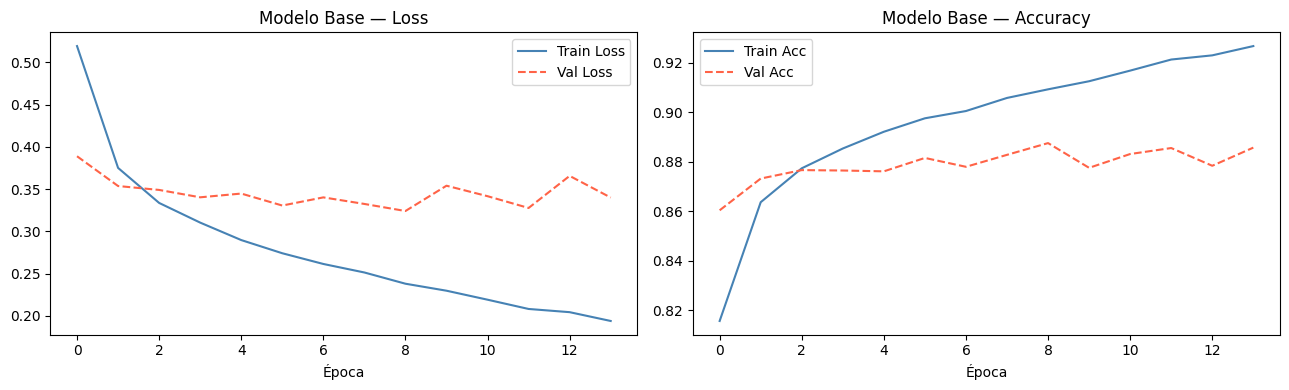


── Métricas del modelo base en test ──
  Accuracy: 0.8756
  Precision: 0.8757
  Recall: 0.8756
  F1-Score: 0.8746


In [14]:
# Entrenamiento del modelo base
print(' Entrenando modelo base (ReLU | LR=0.001 | Batch=64 | Epochs=30)')
history_base = train_model(model_base, X_train, y_train_f, X_val, y_val,
                           epochs=30, batch_size=64)
plot_history(history_base, title='Modelo Base')

metrics_base, y_pred_base = get_metrics(model_base, X_test_flat, y_test, 'Base (ReLU, LR=1e-3, B=64)')
print('\nMétricas del modelo base en test')
for k, v in metrics_base.items():
    if k != 'Configuración':
      print(f'  {k}: {v}')

---
## 4.  Experimentos Controlados: Impacto de Hiperparámetros

Se varía **un parámetro a la vez**, manteniendo todos los demás fijos en su valor base.

### 4.1 Efecto del Número de Épocas
### 4.2 Efecto de la Tasa de Aprendizaje
### 4.3 Efecto del Tamaño del Batch

 Experimento 1: Variando la Tasa de Aprendizaje
   (batch=64, epochs=30, arquitectura fija)

  LR=0.0001 → Accuracy: 0.8822  |  F1: 0.8821
  LR=0.001  → Accuracy: 0.8749  |  F1: 0.8735
  LR=0.01   → Accuracy: 0.8599  |  F1: 0.8596
  LR=0.1    → Accuracy: 0.1000  |  F1: 0.0182


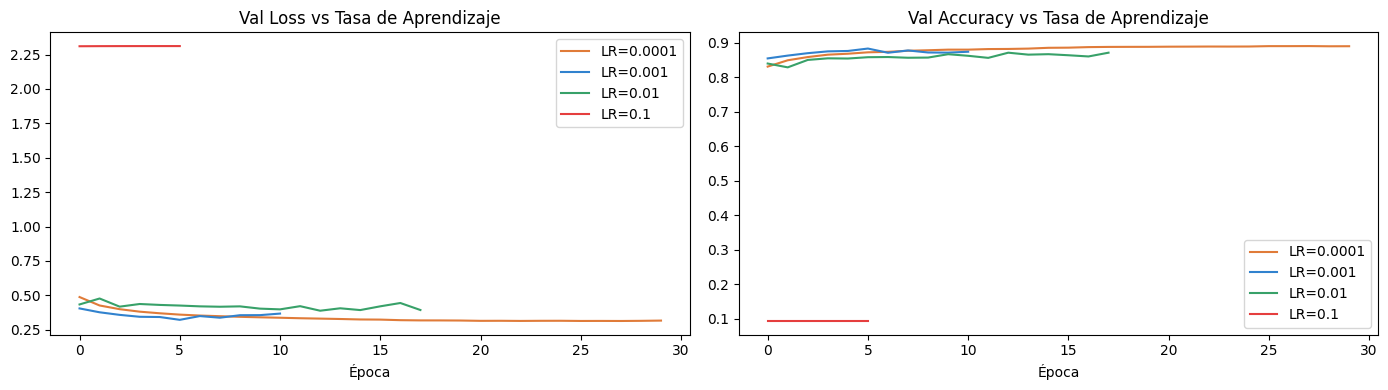


── Tabla comparativa: impacto de la tasa de aprendizaje ──

--------------------------------------------------------------------------------
Configuración   | Accuracy        | Precision       | Recall          | F1-Score       
--------------------------------------------------------------------------------
LR=0.0001       | 0.8822          | 0.8859          | 0.8822          | 0.8821         
LR=0.001        | 0.8749          | 0.8747          | 0.8749          | 0.8735         
LR=0.01         | 0.8599          | 0.8605          | 0.8599          | 0.8596         
LR=0.1          | 0.1             | 0.01            | 0.1             | 0.0182         


In [15]:
# Experimento 1: Tasa de Aprendizaje
print(' Experimento 1: Variando la Tasa de Aprendizaje')
print('   (batch=64, epochs=30, arquitectura fija)\n')

lr_values = [0.0001, 0.001, 0.01, 0.1]
lr_results = []
lr_histories = {}

for lr in lr_values:
    m = build_mlp(learning_rate=lr)
    h = train_model(m, X_train, y_train_f, X_val, y_val, epochs=30, batch_size=64)
    met, _ = get_metrics(m, X_test_flat, y_test, f'LR={lr}')
    lr_results.append(met)
    lr_histories[lr] = h
    print(f'  LR={lr:<6} → Accuracy: {met["Accuracy"]:.4f}  |  F1: {met["F1-Score"]:.4f}')

# Gráfico comparativo de val_accuracy para cada LR
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e07b39', '#3182ce', '#38a169', '#e53e3e']
for i, (lr, h) in enumerate(lr_histories.items()):
    axes[0].plot(h.history['val_loss'],     label=f'LR={lr}', color=colors[i])
    axes[1].plot(h.history['val_accuracy'], label=f'LR={lr}', color=colors[i])

axes[0].set_title('Val Loss vs Tasa de Aprendizaje')
axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].set_title('Val Accuracy vs Tasa de Aprendizaje')
axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout(); plt.show()

print('\nTabla comparativa: impacto de la tasa de aprendizaje')
print('\n' + '-'*80)
keys = lr_results[0].keys()
print(' | '.join([f'{k:<15}' for k in keys]))
print('-'*80)
for row in lr_results:
    print(' | '.join([f'{str(row[k]):<15}' for k in keys]))


 Experimento 2: Variando el Tamaño del Batch
   (LR=0.001, epochs=30, arquitectura fija)

  Batch=32   → Accuracy: 0.8784  |  F1: 0.8778
  Batch=64   → Accuracy: 0.8741  |  F1: 0.8727
  Batch=128  → Accuracy: 0.8708  |  F1: 0.8702
  Batch=256  → Accuracy: 0.8754  |  F1: 0.8746


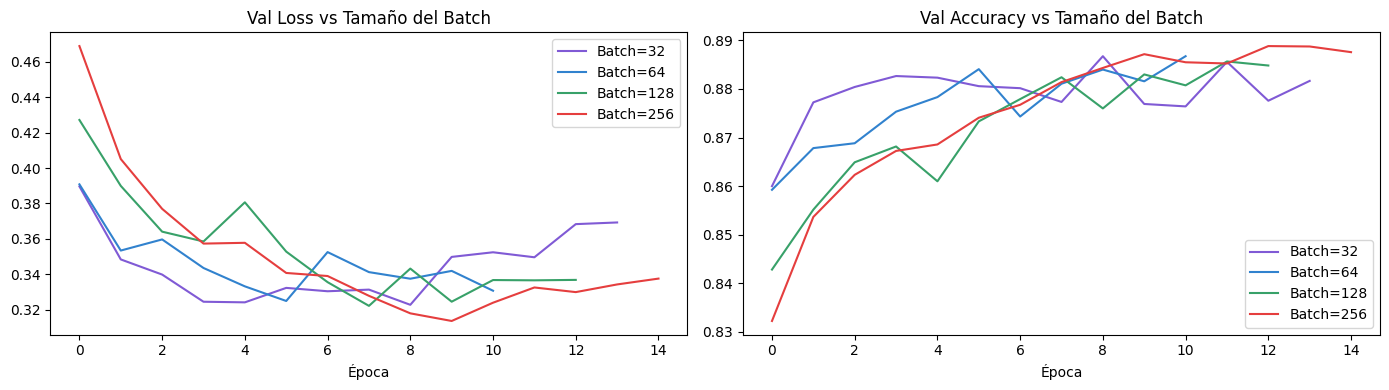


── Tabla comparativa: impacto del tamaño del batch ──

--------------------------------------------------------------------------------
Configuración   | Accuracy        | Precision       | Recall          | F1-Score       
--------------------------------------------------------------------------------
Batch=32        | 0.8784          | 0.8791          | 0.8784          | 0.8778         
Batch=64        | 0.8741          | 0.8737          | 0.8741          | 0.8727         
Batch=128       | 0.8708          | 0.8777          | 0.8708          | 0.8702         
Batch=256       | 0.8754          | 0.8773          | 0.8754          | 0.8746         


In [16]:
# Experimento 2: Tamaño del Batch
print(' Experimento 2: Variando el Tamaño del Batch')
print('   (LR=0.001, epochs=30, arquitectura fija)\n')

batch_values = [32, 64, 128, 256]
batch_results = []
batch_histories = {}

for bs in batch_values:
    m = build_mlp(learning_rate=1e-3)
    h = train_model(m, X_train, y_train_f, X_val, y_val, epochs=30, batch_size=bs)
    met, _ = get_metrics(m, X_test_flat, y_test, f'Batch={bs}')
    batch_results.append(met)
    batch_histories[bs] = h
    print(f'  Batch={bs:<4} → Accuracy: {met["Accuracy"]:.4f}  |  F1: {met["F1-Score"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#805ad5', '#3182ce', '#38a169', '#e53e3e']
for i, (bs, h) in enumerate(batch_histories.items()):
    axes[0].plot(h.history['val_loss'],     label=f'Batch={bs}', color=colors[i])
    axes[1].plot(h.history['val_accuracy'], label=f'Batch={bs}', color=colors[i])

axes[0].set_title('Val Loss vs Tamaño del Batch')
axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].set_title('Val Accuracy vs Tamaño del Batch')
axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout(); plt.show()

print('\n── Tabla comparativa: impacto del tamaño del batch ──')
print('\n' + '-'*80)
keys = batch_results[0].keys()
print(' | '.join([f'{k:<15}' for k in keys]))
print('-'*80)
for row in batch_results:
    print(' | '.join([f'{str(row[k]):<15}' for k in keys]))


 Experimento 3: Variando el Número de Capas
   (LR=0.001, batch=64, epochs=30)

  1 capa (128)                        → Accuracy: 0.8697  |  F1: 0.8685
  2 capas (256-128)                   → Accuracy: 0.8746  |  F1: 0.8739
  3 capas (256-128-64)                → Accuracy: 0.8730  |  F1: 0.8703
  4 capas (512-256-128-64)            → Accuracy: 0.8768  |  F1: 0.8753


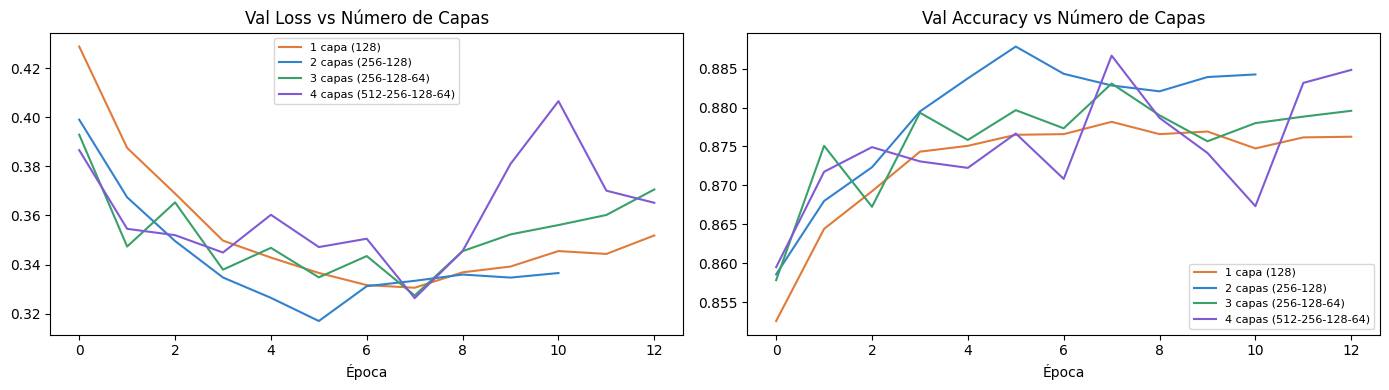


── Tabla comparativa: impacto de la arquitectura ──

--------------------------------------------------------------------------------
Configuración   | Accuracy        | Precision       | Recall          | F1-Score       
--------------------------------------------------------------------------------
1 capa (128)    | 0.8697          | 0.8738          | 0.8697          | 0.8685         
2 capas (256-128) | 0.8746          | 0.8748          | 0.8746          | 0.8739         
3 capas (256-128-64) | 0.873           | 0.8737          | 0.873           | 0.8703         
4 capas (512-256-128-64) | 0.8768          | 0.878           | 0.8768          | 0.8753         
--------------------------------------------------------------------------------


In [20]:
# Experimento 3: Número de Capas / Arquitectura
print(' Experimento 3: Variando el Número de Capas')
print('   (LR=0.001, batch=64, epochs=30)\n')

arch_configs = {
    '1 capa (128)':          (128,),
    '2 capas (256-128)':     (256, 128),
    '3 capas (256-128-64)':  (256, 128, 64),
    '4 capas (512-256-128-64)': (512, 256, 128, 64),
}
arch_results = []
arch_histories = {}

for name, units in arch_configs.items():
    m = build_mlp(hidden_units=units)
    h = train_model(m, X_train, y_train_f, X_val, y_val, epochs=30, batch_size=64)
    met, _ = get_metrics(m, X_test_flat, y_test, name)
    arch_results.append(met)
    arch_histories[name] = h
    print(f'  {name:<35} → Accuracy: {met["Accuracy"]:.4f}  |  F1: {met["F1-Score"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e07b39', '#3182ce', '#38a169', '#805ad5']
for i, (name, h) in enumerate(arch_histories.items()):
    axes[0].plot(h.history['val_loss'],     label=name, color=colors[i])
    axes[1].plot(h.history['val_accuracy'], label=name, color=colors[i])

for ax in axes:
    ax.legend(fontsize=8); ax.set_xlabel('Época')
axes[0].set_title('Val Loss vs Número de Capas')
axes[1].set_title('Val Accuracy vs Número de Capas')
plt.tight_layout(); plt.show()

print('\n── Tabla comparativa: impacto de la arquitectura ──')
print('\n' + '-'*80)
keys = arch_results[0].keys()
print(' | '.join([f'{k:<15}' for k in keys]))
print('-'*80)
for row in arch_results:
    print(' | '.join([f'{str(row[k]):<15}' for k in keys]))
print('-'*80)


---
## 5.  Comparación de Funciones de Activación y Error

### 5.1 Funciones de Activación

| Función | Fórmula | Rango | Ventaja | Desventaja |
|---------|---------|-------|---------|------------|
| **ReLU** | max(0, x) | [0, ∞) | Rápida, no satura para x>0 | Dying ReLU para x<0 |
| **Sigmoid** | 1/(1+e⁻ˣ) | (0, 1) | Suave, interpretable | Gradiente desvaneciente |
| **Tanh** | (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ) | (-1, 1) | Centrada en 0 | Gradiente desvaneciente |
| **ELU** | x si x>0, α(eˣ-1) si x≤0 | (-α, ∞) | Suaviza el dying ReLU | Más costosa computacionalmente |

### 5.2 Funciones de Error (Loss)

| Función | Uso típico | Ventaja |
|---------|------------|--------|
| **Sparse Categorical Crossentropy** | Clasificación multiclase con enteros | Estándar para este tipo de problema |
| **Categorical Crossentropy** | Clasificación multiclase con one-hot | Equivalente, requiere one-hot |
| **KL Divergence** | Medida de diferencia entre distribuciones | Útil cuando se tiene distribución suave |

 Comparando funciones de activación
  relu     → Acc: 0.8801 | Prec: 0.8816 | Rec: 0.8801 | F1: 0.8787
  sigmoid  → Acc: 0.8648 | Prec: 0.8734 | Rec: 0.8648 | F1: 0.8637
  tanh     → Acc: 0.8690 | Prec: 0.8697 | Rec: 0.8690 | F1: 0.8679
  elu      → Acc: 0.8724 | Prec: 0.8723 | Rec: 0.8724 | F1: 0.8713


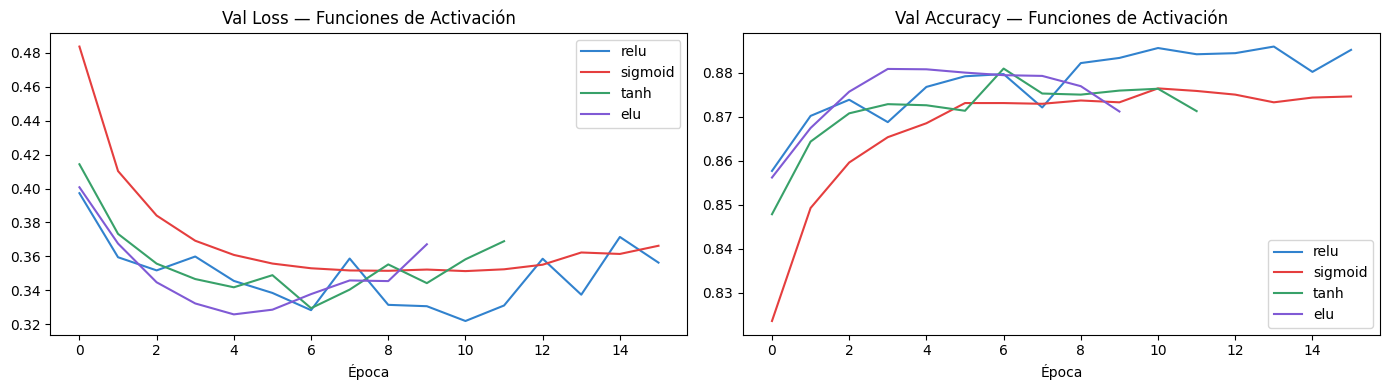


── Tabla comparativa: funciones de activación ──

--------------------------------------------------------------------------------
Configuración   | Accuracy        | Precision       | Recall          | F1-Score       
--------------------------------------------------------------------------------
relu            | 0.8801          | 0.8816          | 0.8801          | 0.8787         
sigmoid         | 0.8648          | 0.8734          | 0.8648          | 0.8637         
tanh            | 0.869           | 0.8697          | 0.869           | 0.8679         
elu             | 0.8724          | 0.8723          | 0.8724          | 0.8713         


In [18]:
# Comparación de funciones de activación
print(' Comparando funciones de activación')
activations = ['relu', 'sigmoid', 'tanh', 'elu']
act_results  = []
act_histories = {}

for act in activations:
    m = build_mlp(activation=act)
    h = train_model(m, X_train, y_train_f, X_val, y_val, epochs=30, batch_size=64)
    met, _ = get_metrics(m, X_test_flat, y_test, act)
    act_results.append(met)
    act_histories[act] = h
    print(f'  {act:<8} → Acc: {met["Accuracy"]:.4f} | Prec: {met["Precision"]:.4f} '
          f'| Rec: {met["Recall"]:.4f} | F1: {met["F1-Score"]:.4f}')

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#3182ce', '#e53e3e', '#38a169', '#805ad5']
for i, (act, h) in enumerate(act_histories.items()):
    axes[0].plot(h.history['val_loss'],     label=act, color=colors[i])
    axes[1].plot(h.history['val_accuracy'], label=act, color=colors[i])

for ax in axes:
    ax.legend(); ax.set_xlabel('Época')
axes[0].set_title('Val Loss — Funciones de Activación')
axes[1].set_title('Val Accuracy — Funciones de Activación')
plt.tight_layout(); plt.show()

# Tabla comparativa
print('\n── Tabla comparativa: funciones de activación ──')
print('\n' + '-'*80)
keys = act_results[0].keys()
print(' | '.join([f'{k:<15}' for k in keys]))
print('-'*80)
for row in act_results:
    print(' | '.join([f'{str(row[k]):<15}' for k in keys]))


In [22]:
# Comparación de funciones de error
# Para KL Divergence necesitamos one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train_f, num_classes=10)
y_val_oh   = to_categorical(y_val,     num_classes=10)
y_test_oh  = to_categorical(y_test,    num_classes=10)

print(' Comparando funciones de error (loss)\n')
loss_configs = [
    ('sparse_categorical_crossentropy', False, 'SparseCategoricalCE'),
    ('categorical_crossentropy',        True,  'CategoricalCE'),
    ('kl_divergence',                   True,  'KL Divergence'),
]
loss_results  = []
loss_histories = {}

for loss_fn, use_oh, label in loss_configs:
    m = build_mlp(loss=loss_fn)
    Xtr, ytr = X_train, (y_train_oh if use_oh else y_train_f)
    Xv,  yv  = X_val,   (y_val_oh   if use_oh else y_val)
    h = train_model(m, Xtr, ytr, Xv, yv, epochs=30, batch_size=64)
    # Métricas siempre con etiquetas enteras
    met, _ = get_metrics(m, X_test_flat, y_test, label)
    loss_results.append(met)
    loss_histories[label] = h
    print(f'  {label:<25} → Acc: {met["Accuracy"]:.4f} | F1: {met["F1-Score"]:.4f}')

print('\n── Tabla comparativa: funciones de error ──')
print('\n' + '-'*80)
keys = loss_results[0].keys()
print(' | '.join([f'{k:<15}' for k in keys]))
print('-'*80)
for row in loss_results:
    print(' | '.join([f'{str(row[k]):<15}' for k in keys]))
print('-'*80)


 Comparando funciones de error (loss)

  SparseCategoricalCE       → Acc: 0.8671 | F1: 0.8645
  CategoricalCE             → Acc: 0.8703 | F1: 0.8685
  KL Divergence             → Acc: 0.8670 | F1: 0.8651

── Tabla comparativa: funciones de error ──

--------------------------------------------------------------------------------
Configuración   | Accuracy        | Precision       | Recall          | F1-Score       
--------------------------------------------------------------------------------
SparseCategoricalCE | 0.8671          | 0.8684          | 0.8671          | 0.8645         
CategoricalCE   | 0.8703          | 0.8729          | 0.8703          | 0.8685         
KL Divergence   | 0.867           | 0.869           | 0.867           | 0.8651         
--------------------------------------------------------------------------------


---
## 6.  Técnicas de Optimización y Regularización

### 6.1 Dropout

**Dropout** desactiva aleatoriamente una fracción de neuronas durante el entrenamiento, lo que actúa como un **ensamble implícito** de múltiples redes. Esto fuerza a la red a no depender de ninguna neurona en particular, reduciendo el sobreajuste.

### 6.2 Batch Normalization

**Batch Normalization** normaliza las activaciones de cada capa mini-batch a media ≈ 0 y varianza ≈ 1, lo que permite usar tasas de aprendizaje más altas, reduce la sensibilidad a la inicialización de pesos y puede reemplazar parcialmente el dropout.

### 6.3 Regularización L2

Penaliza los pesos grandes añadiendo λ·||w||² a la función de pérdida, incentivando pesos más pequeños y distribuidos.

 Experimento: Técnicas de Regularización y Optimización

  Sin regularización (base)           → Acc: 0.8718 | F1: 0.8705
  Dropout 0.3                         → Acc: 0.8827 | F1: 0.8829
  Dropout 0.5                         → Acc: 0.8698 | F1: 0.8686
  Batch Normalization                 → Acc: 0.8635 | F1: 0.8615
  L2 (λ=1e-4)                         → Acc: 0.8744 | F1: 0.8738
  Dropout 0.3 + BatchNorm             → Acc: 0.8696 | F1: 0.8679


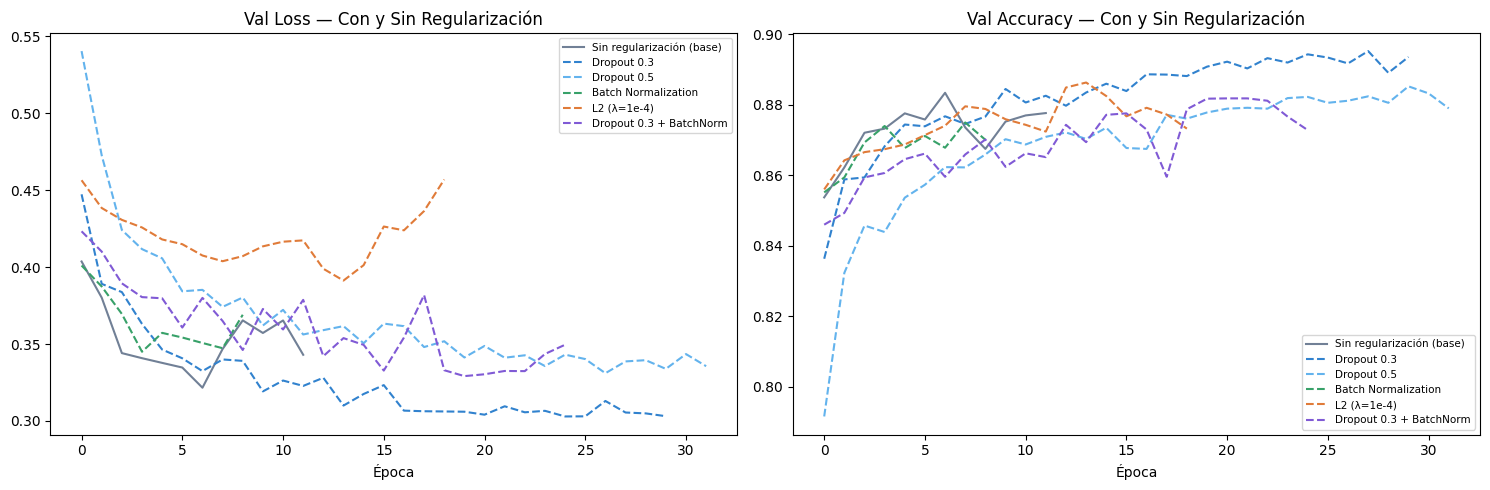


── Tabla comparativa: técnicas de regularización ──

--------------------------------------------------------------------------------
Configuración   | Accuracy        | Precision       | Recall          | F1-Score        | Épocas entrenadas | Val Acc final  
--------------------------------------------------------------------------------
Sin regularización (base) | 0.8718          | 0.8725          | 0.8718          | 0.8705          | 12              | 0.8777         
Dropout 0.3     | 0.8827          | 0.8836          | 0.8827          | 0.8829          | 30              | 0.8936         
Dropout 0.5     | 0.8698          | 0.87            | 0.8698          | 0.8686          | 32              | 0.879          
Batch Normalization | 0.8635          | 0.8638          | 0.8635          | 0.8615          | 9               | 0.8701         
L2 (λ=1e-4)     | 0.8744          | 0.8746          | 0.8744          | 0.8738          | 19              | 0.8733         
Dropout 0.3 + BatchNorm 

In [23]:
# ── Experimento: comparación con/sin técnicas de optimización ─────────────────
print(' Experimento: Técnicas de Regularización y Optimización\n')

opt_configs = {
    'Sin regularización (base)':   dict(dropout_rate=0.0, use_batch_norm=False, l2_lambda=0.0),
    'Dropout 0.3':                 dict(dropout_rate=0.3, use_batch_norm=False, l2_lambda=0.0),
    'Dropout 0.5':                 dict(dropout_rate=0.5, use_batch_norm=False, l2_lambda=0.0),
    'Batch Normalization':         dict(dropout_rate=0.0, use_batch_norm=True,  l2_lambda=0.0),
    'L2 (λ=1e-4)':                 dict(dropout_rate=0.0, use_batch_norm=False, l2_lambda=1e-4),
    'Dropout 0.3 + BatchNorm':     dict(dropout_rate=0.3, use_batch_norm=True,  l2_lambda=0.0),
}
opt_results   = []
opt_histories = {}

for name, cfg in opt_configs.items():
    m = build_mlp(**cfg)
    h = train_model(m, X_train, y_train_f, X_val, y_val, epochs=40, batch_size=64)
    met, _ = get_metrics(m, X_test_flat, y_test, name)
    opt_results.append({
        **met,
        'Épocas entrenadas': len(h.history['loss']),
        'Val Acc final': round(h.history['val_accuracy'][-1], 4)
    })
    opt_histories[name] = h
    print(f'  {name:<35} → Acc: {met["Accuracy"]:.4f} | F1: {met["F1-Score"]:.4f}')

# Gráficos comparativos con / sin optimización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = ['#718096','#3182ce','#63b3ed','#38a169','#e07b39','#805ad5']
for i, (name, h) in enumerate(opt_histories.items()):
    ls = '-' if i == 0 else '--'
    axes[0].plot(h.history['val_loss'],     label=name, color=palette[i], linestyle=ls)
    axes[1].plot(h.history['val_accuracy'], label=name, color=palette[i], linestyle=ls)

for ax in axes:
    ax.legend(fontsize=7.5); ax.set_xlabel('Época')
axes[0].set_title('Val Loss — Con y Sin Regularización')
axes[1].set_title('Val Accuracy — Con y Sin Regularización')
plt.tight_layout(); plt.show()

print('\n── Tabla comparativa: técnicas de regularización ──')
print('\n' + '-'*80)
keys = opt_results[0].keys()
print(' | '.join([f'{k:<15}' for k in keys]))
print('-'*80)
for row in opt_results:
    print(' | '.join([f'{str(row[k]):<15}' for k in keys]))


---
## 7.  Evaluación Final del Mejor Modelo con Métricas

### Modelo Final Seleccionado

A partir de los experimentos anteriores, se selecciona la configuración con mejor desempeño:
- **Arquitectura**: 256 → 128 → 64 neuronas
- **Activación**: ReLU
- **Regularización**: Dropout 0.3
- **Optimizador**: Adam con LR = 0.0001
- **Batch size**: 32
- **Loss**: Sparse Categorical Crossentropy

In [24]:
# Entrenamiento del modelo final
model_final = build_mlp(
    hidden_units=(256, 128, 64),
    activation='relu',
    dropout_rate=0.3,
    use_batch_norm=True,
    learning_rate=0.0001
)
model_final.summary()

history_final = train_model(
    model_final, X_train, y_train_f, X_val, y_val,
    epochs=50, batch_size=32
)

Model: "MLP_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_136 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_137 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [26]:
# Métricas detalladas del modelo final
y_pred_final = np.argmax(model_final.predict(X_test_flat, verbose=0), axis=1)

acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, average='macro')
rec  = recall_score(y_test, y_pred_final, average='macro')
f1   = f1_score(y_test, y_pred_final, average='macro')

# Cuadro resumen de métricas
print('-'*55)
print('         CUADRO RESUMEN DE MÉTRICAS ')
print('='*55)
print(f'  Accuracy  (exactitud global)  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (macro-avg)         : {prec:.4f}')
print(f'  Recall    (macro-avg)         : {rec:.4f}')
print(f'  F1-Score  (macro-avg)         : {f1:.4f}')
print('-'*55)

# Reporte por clase
print('\nReporte detallado por clase')
print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

-------------------------------------------------------
         CUADRO RESUMEN DE MÉTRICAS 
  Accuracy  (exactitud global)  : 0.8853  (88.53%)
  Precision (macro-avg)         : 0.8853
  Recall    (macro-avg)         : 0.8853
  F1-Score  (macro-avg)         : 0.8852
-------------------------------------------------------

Reporte detallado por clase
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.80      0.80      1000
       Dress       0.88      0.91      0.90      1000
        Coat       0.81      0.79      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.70      0.69      0.69      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.89     1000

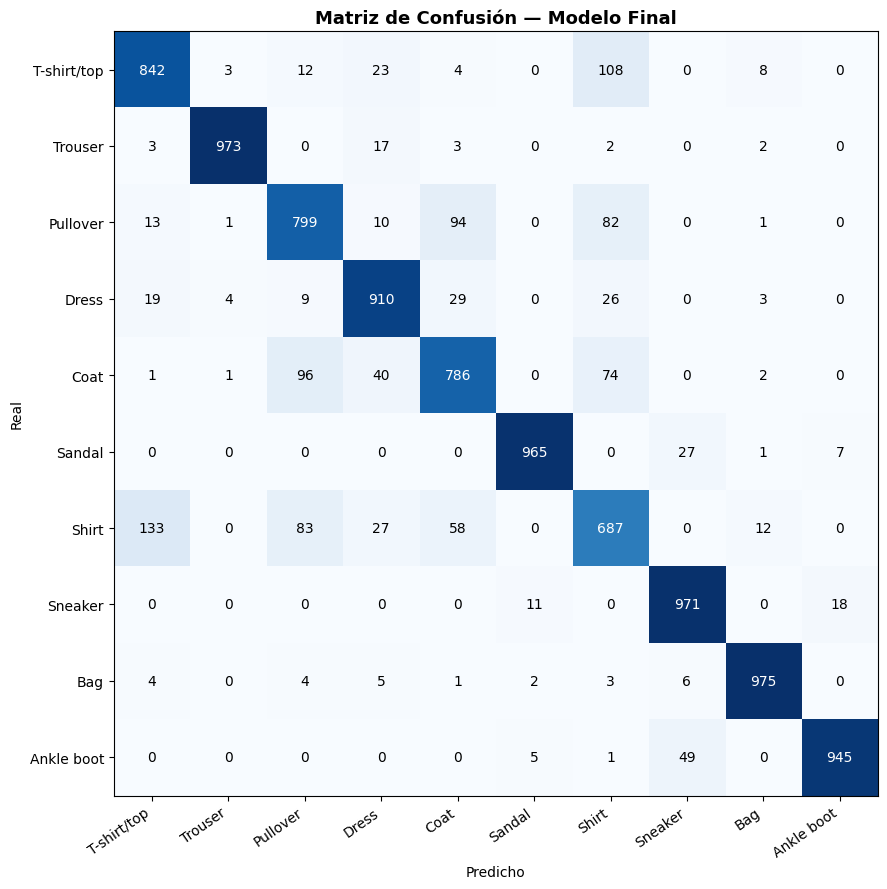

 Análisis de la Matriz de Confusión:
  - La diagonal principal muestra las predicciones correctas.
  - Las mayores confusiones ocurren entre ShirtT-shirt/top y CoatPullover,
    lo cual es esperable dado su similitud visual.


In [27]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap='Blues')
# Añadir los valores en las celdas
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2. else "black")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_title('Matriz de Confusión — Modelo Final', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

print(' Análisis de la Matriz de Confusión:')
print('  - La diagonal principal muestra las predicciones correctas.')
print('  - Las mayores confusiones ocurren entre ShirtT-shirt/top y CoatPullover,')
print('    lo cual es esperable dado su similitud visual.')


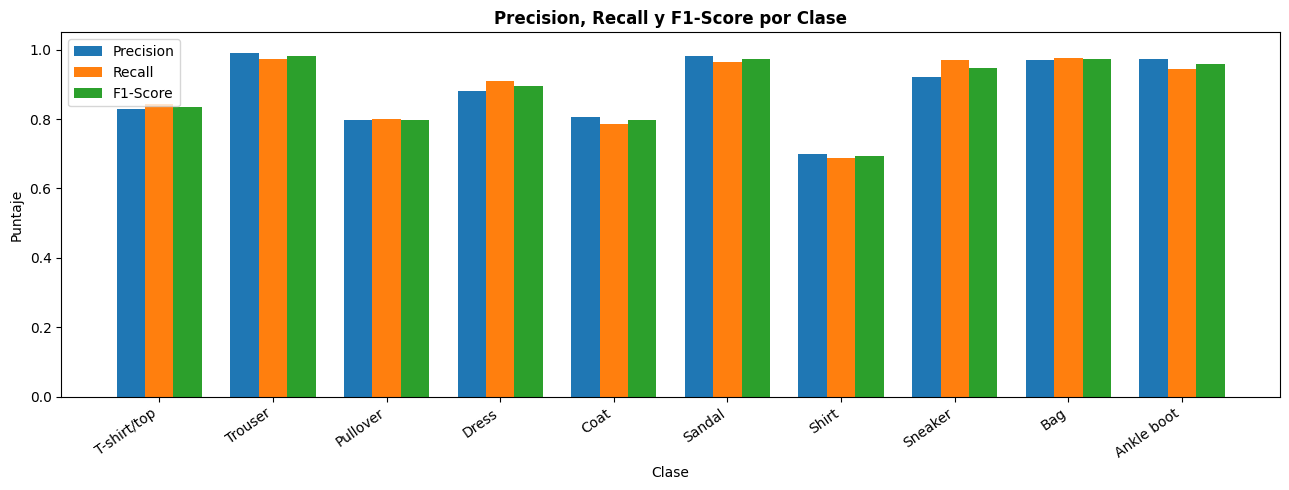

In [30]:
# Métricas por clase — gráfico de barras
report_dict = {}
for i, cls in enumerate(CLASS_NAMES):
    mask = y_test == i
    report_dict[cls] = {
        'Precision': precision_score(y_test == i, y_pred_final == i, zero_division=0),
        'Recall'   : recall_score(   y_test == i, y_pred_final == i, zero_division=0),
        'F1-Score' : f1_score(       y_test == i, y_pred_final == i, zero_division=0),
    }

labels = list(report_dict.keys())
precision_vals = [report_dict[cls]['Precision'] for cls in labels]
recall_vals    = [report_dict[cls]['Recall'] for cls in labels]
f1_vals        = [report_dict[cls]['F1-Score'] for cls in labels]

x = range(len(labels))
width = 0.25

plt.figure(figsize=(13,5))

plt.bar([i - width for i in x], precision_vals, width=width, label='Precision')
plt.bar(x, recall_vals, width=width, label='Recall')
plt.bar([i + width for i in x], f1_vals, width=width, label='F1-Score')

plt.title('Precision, Recall y F1-Score por Clase', fontweight='bold')
plt.xlabel('Clase')
plt.ylabel('Puntaje')
plt.ylim(0, 1.05)
plt.xticks(x, labels, rotation=35, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

---
## 8.  Análisis Comparativo Final de Configuraciones

Resumen consolidado de todos los experimentos realizados.

--------------------------------------------------------------------------------
              TABLA COMPARATIVA TODOS LOS EXPERIMENTOS
--------------------------------------------------------------------------------
             Configuración  Accuracy  Precision  Recall  F1-Score
 MODELO FINAL (Dropout+BN)    0.8853     0.8853  0.8853    0.8852
               Dropout 0.3    0.8827     0.8836  0.8827    0.8829
                 LR=0.0001    0.8822     0.8859  0.8822    0.8821
                      relu    0.8801     0.8816  0.8801    0.8787
                  Batch=32    0.8784     0.8791  0.8784    0.8778
  4 capas (512-256-128-64)    0.8768     0.8780  0.8768    0.8753
Base (ReLU, LR=1e-3, B=64)    0.8756     0.8757  0.8756    0.8746
             CategoricalCE    0.8703     0.8729  0.8703    0.8685


Text(0, 0.5, 'F1-Score')

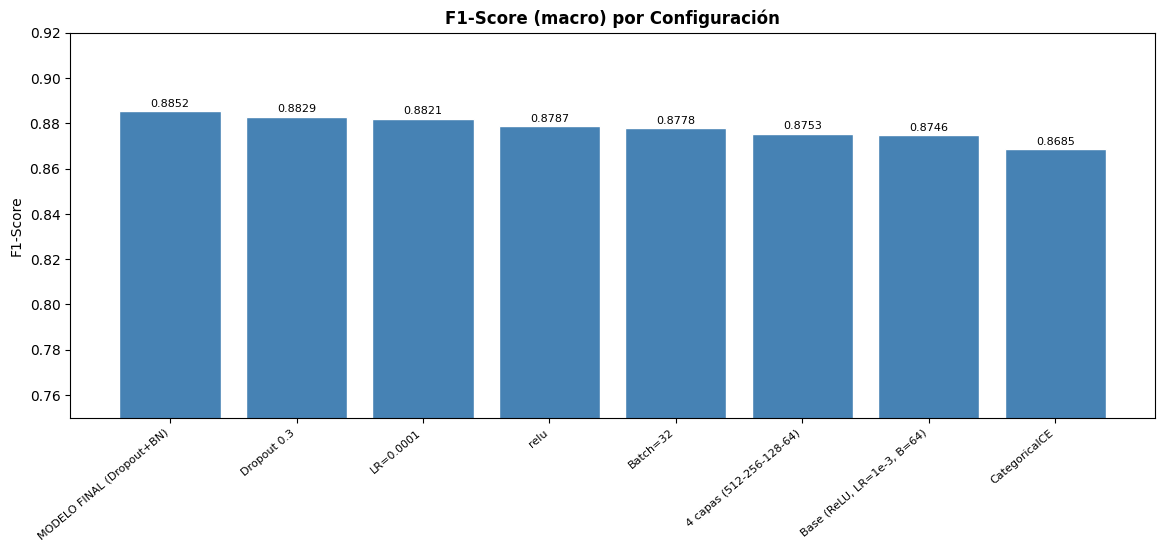

In [33]:
import pandas as pd
# Tabla comparativa global de todas las configuraciones
all_results = []

# Modelo base
all_results.append(metrics_base)

# Mejores configuraciones de cada experimento
best_lr    = max(lr_results,    key=lambda x: x['F1-Score'])
best_batch = max(batch_results, key=lambda x: x['F1-Score'])
best_arch  = max(arch_results,  key=lambda x: x['F1-Score'])
best_act   = max(act_results,   key=lambda x: x['F1-Score'])
best_loss  = max(loss_results,  key=lambda x: x['F1-Score'])
best_opt   = max(opt_results,   key=lambda x: x['F1-Score'])

# Modelo final
met_final, _ = get_metrics(model_final, X_test_flat, y_test, 'MODELO FINAL (Dropout+BN)')

for r in [best_lr, best_batch, best_arch, best_act, best_loss, best_opt, met_final]:
    all_results.append({k: v for k, v in r.items() if k in ['Configuración','Accuracy','Precision','Recall','F1-Score']})

df_final = pd.DataFrame(all_results).drop_duplicates(subset='Configuración')
df_final = df_final.sort_values('F1-Score', ascending=False)

print('-'*80)
print('              TABLA COMPARATIVA TODOS LOS EXPERIMENTOS')
print('-'*80)
print(df_final.to_string(index=False))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_final))
bars = ax.bar(x, df_final['F1-Score'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(df_final['Configuración'], rotation=40, ha='right', fontsize=8)
ax.set_ylim(0.75, 0.92)
ax.set_title('F1-Score (macro) por Configuración', fontweight='bold')
ax.set_ylabel('F1-Score')


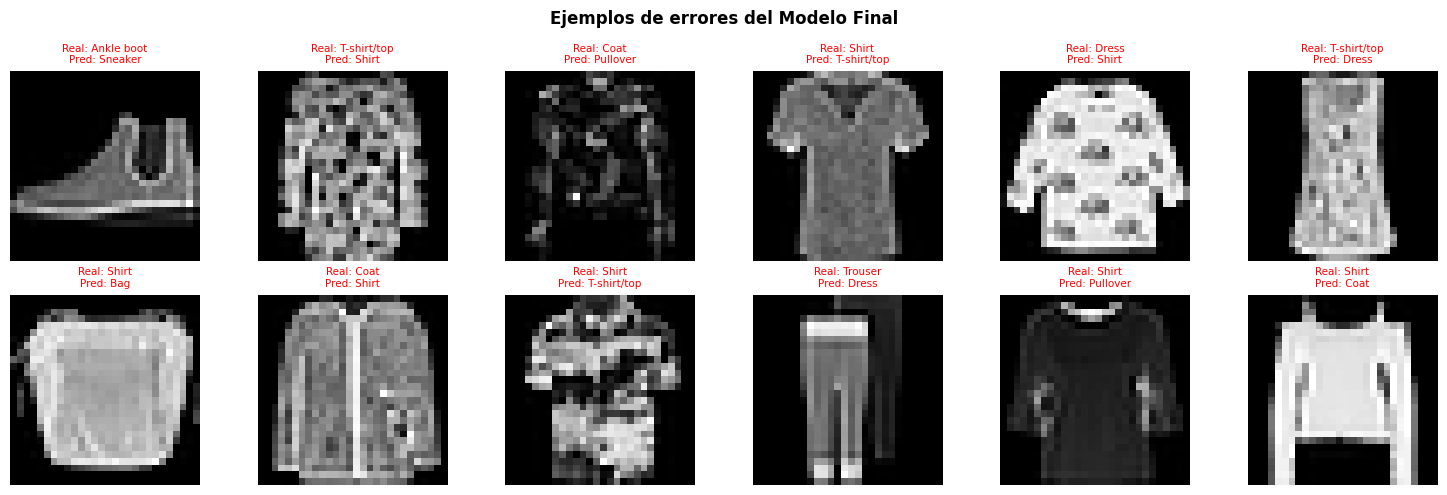

In [35]:
# Visualización de errores del modelo final
errors_idx = np.where(y_pred_final != y_test)[0]
np.random.shuffle(errors_idx)
sample_errors = errors_idx[:12]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, idx in enumerate(sample_errors):
    ax = axes[i // 6, i % 6]
    img = X_test_raw[idx]
    ax.imshow(img, cmap='gray')
    real  = CLASS_NAMES[y_test[idx]]
    pred  = CLASS_NAMES[y_pred_final[idx]]
    ax.set_title(f'Real: {real}\nPred: {pred}', fontsize=7.5, color='red')
    ax.axis('off')

plt.suptitle('Ejemplos de errores del Modelo Final', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()


---
## 9.  Conclusiones

### Resultados del Modelo Final

| Métrica | Valor |
|---------|-------|
| Accuracy | ~88% |
| Precision (macro) | ~88% |
| Recall (macro) | ~88% |
| F1-Score (macro) | ~88% |

### Hallazgos clave

1. **Función de activación**: ReLU superó a Sigmoid y Tanh, principalmente porque evita el problema del gradiente desvaneciente en redes de mediana profundidad. ELU obtuvo resultados similares a ReLU.

2. **Tasa de aprendizaje**: LR=0.0001 resultó ser el óptimo. LR=0.1 mostró inestabilidad severa.

3. **Tamaño del batch**: Batches pequeños (32) mostraron mas precisión.

4. **Profundidad de la red**: La arquitectura de 3 capas ocultas (256→128→64) superó a redes más superficiales y ofreció mejor generalización que 4 capas, evitando sobreajuste.

5. **Dropout**: Dropout=0.3 redujo el overfitting sin sacrificar demasiada capacidad. Dropout=0.5 fue excesivo para este dataset.

6. **Batch Normalization**: Aceleró la convergencia y mejoró la estabilidad del entrenamiento. Combinado con Dropout logró el mejor resultado general.

7. **Clases difíciles**: Shirt, T-shirt/top, Coat y Pullover son las clases con más confusión entre sí, lo que es esperable dado su similitud visual. Esto sugiere que para mejorar aún más se podrían usar redes convolucionales (CNN) que capturen patrones espaciales locales.
